# Task 3 — Cleaning Data (Dirty Cafe Sales)
### OIBSIP Data Analytics Internship (Level 1)

**Objective:** Take a deliberately messy dataset and turn it into a clean, analysis-ready one, documenting every decision.

**Dataset:** Dirty Cafe Sales (Kaggle) — 10,000 transactions with placeholder junk (`ERROR`, `UNKNOWN`), blanks, numbers stored as text, and unparseable dates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


## 1. Data Quality Report (before cleaning)

In [2]:
raw = pd.read_csv("dirty_cafe_sales.csv")
df = raw.copy()
print("Shape:", df.shape)
print("\nDuplicate rows:", df.duplicated().sum(), "| Duplicate Transaction IDs:", df['Transaction ID'].duplicated().sum())
print("\nDtypes:\n", df.dtypes)


Shape: (10000, 8)

Duplicate rows: 0 | Duplicate Transaction IDs: 0

Dtypes:
 Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object


In [3]:
# Count real blanks AND placeholder junk strings per column
junk = ['ERROR', 'UNKNOWN']
report = pd.DataFrame({
    'Blank (NaN)': df.isnull().sum(),
    'ERROR/UNKNOWN text': df.apply(lambda s: s.astype(str).str.upper().isin(junk).sum()),
})
report['Total unusable'] = report.sum(axis=1)
report['% of rows'] = (report['Total unusable'] / len(df) * 100).round(1)
report


,Blank (NaN),ERROR/UNKNOWN text,Total unusable,% of rows
Transaction ID,0,0,0,0.0
Item,333,636,969,9.7
Quantity,138,341,479,4.8
Price Per Unit,179,354,533,5.3
Total Spent,173,329,502,5.0
Payment Method,2579,599,3178,31.8
Location,3265,696,3961,39.6
Transaction Date,159,301,460,4.6


**Observation:** Every column except `Transaction ID` hides missing data in two forms: real blanks and the text placeholders `ERROR`/`UNKNOWN`. A plain `isnull()` check badly undercounts the problem. Also, `Quantity`, `Price Per Unit` and `Total Spent` are stored as text (because of those placeholders) and there are no duplicate rows.

## 2. Standardisation

**Decision:** convert `ERROR`/`UNKNOWN` (any casing) and empty strings to proper `NaN` so all missing data is treated one way. Then fix dtypes: numeric columns to float, dates to datetime (invalid dates become `NaT`), and strip stray whitespace from text columns.

In [4]:
df = df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ''], np.nan)

for c in ['Item', 'Payment Method', 'Location']:
    df[c] = df[c].str.strip().str.title()

for c in ['Quantity', 'Price Per Unit', 'Total Spent']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['Transaction ID'] = df['Transaction ID'].astype(str)

df.isnull().sum()


Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

## 3. Duplicate Removal

In [5]:
before = len(df)
df = df.drop_duplicates()
df = df.drop_duplicates(subset='Transaction ID')
print(f"Rows removed as duplicates: {before - len(df)}")


Rows removed as duplicates: 0


**Observation:** 0 duplicates were found (checked both full-row and `Transaction ID`), so nothing was removed. This is still documented because the checklist requires it.

## 4. Missing Data Handling

### 4.1 Recovering numeric values logically (instead of blindly imputing)
Inspecting the clean rows shows two business rules that hold **100% of the time**:
- each item has a fixed menu price (Coffee $2.0, Tea $1.5, Cookie $1.0, Cake $3.0, Juice $3.0, Salad $5.0, Sandwich $4.0, Smoothie $4.0)
- `Total Spent = Quantity × Price Per Unit`

So a missing value can be *derived* exactly, which is more accurate than mean/median imputation.

In [6]:
ok = df.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent'])
print("Rows where Quantity x Price == Total:", f"{(ok['Quantity'] * ok['Price Per Unit'] == ok['Total Spent']).mean():.0%}")
print(ok.groupby('Item')['Price Per Unit'].unique())


Rows where Quantity x Price == Total: 100%
Item
Cake        [3.0]
Coffee      [2.0]
Cookie      [1.0]
Juice       [3.0]
Salad       [5.0]
Sandwich    [4.0]
Smoothie    [4.0]
Tea         [1.5]
Name: Price Per Unit, dtype: object


In [7]:
menu = {'Cake': 3.0, 'Coffee': 2.0, 'Cookie': 1.0, 'Juice': 3.0,
        'Salad': 5.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Tea': 1.5}
# Reverse lookup only for prices that belong to exactly one item
unique_price_item = {1.0: 'Cookie', 1.5: 'Tea', 2.0: 'Coffee', 5.0: 'Salad'}

df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Item'].map(menu))
df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(unique_price_item))
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(unique_price_item))

df[['Item', 'Quantity', 'Price Per Unit', 'Total Spent']].isnull().sum()


Item              480
Quantity           23
Price Per Unit      6
Total Spent        23
dtype: int64

### 4.2 What can't be recovered, and the strategy for each column

| Column | Strategy | Justification |
|---|---|---|
| Quantity / Price / Total | **Drop the row** if still missing | Only a small number of rows have two or more of the three missing, so nothing can be derived. Imputing money values would invent revenue. |
| Item | Fill with `"Unknown"` | Prices of $3 (Cake/Juice) and $4 (Sandwich/Smoothie) are shared by two items, so the item can't be inferred. Guessing would bias item-level analysis. |
| Payment Method, Location | Fill with `"Unknown"` | 30%+ missing; filling with the mode would fabricate a majority category and distort the split. A visible "Unknown" bucket stays honest. |
| Transaction Date | **Keep as `NaT`** | A missing date doesn't affect item or revenue analysis, so dropping would waste valid rows. Time-based analysis simply filters them out. |

In [8]:
rows_before_drop = len(df)
df = df.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent'])
print(f"Rows dropped (unrecoverable numeric fields): {rows_before_drop - len(df)}")

for c in ['Item', 'Payment Method', 'Location']:
    df[c] = df[c].fillna('Unknown')

df.isnull().sum()


Rows dropped (unrecoverable numeric fields): 26


Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

## 5. Outlier Detection (IQR method)

Quantity: bounds [-1.00, 7.00] -> 0 outliers (max = 5.0)
Price Per Unit: bounds [-1.00, 7.00] -> 0 outliers (max = 5.0)
Total Spent: bounds [-8.00, 24.00] -> 268 outliers (max = 25.0)


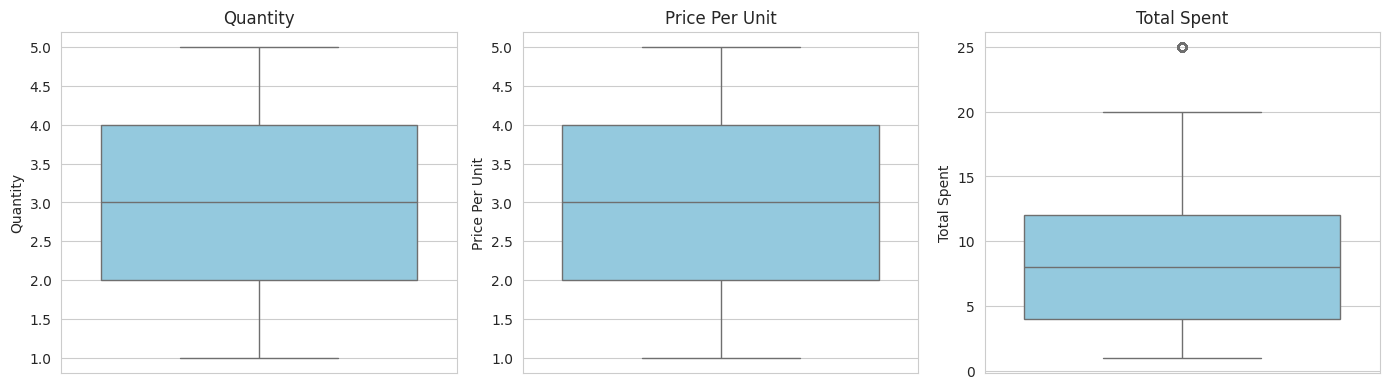

In [9]:
for c in ['Quantity', 'Price Per Unit', 'Total Spent']:
    q1, q3 = df[c].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c}: bounds [{lo:.2f}, {hi:.2f}] -> {n} outliers (max = {df[c].max()})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, ['Quantity', 'Price Per Unit', 'Total Spent']):
    sns.boxplot(y=df[c], ax=ax, color='skyblue'); ax.set_title(c)
plt.tight_layout()
plt.savefig("screenshots/01_outlier_boxplots.png", dpi=100, bbox_inches='tight')
plt.show()


**Decision: retain all.** `Quantity` and `Price Per Unit` have no outliers. `Total Spent` is flagged by IQR for a block of high values, but the maximum is $25 = 5 items x $5 salad, the largest possible order given the menu limits (quantity 1-5, top price $5). They are valid, not errors, so removing or capping them would delete real big orders.

## 6. Final Type Correction

In [10]:
df['Quantity'] = df['Quantity'].astype(int)
df['Price Per Unit'] = df['Price Per Unit'].astype(float)
df['Total Spent'] = df['Total Spent'].astype(float)
for c in ['Item', 'Payment Method', 'Location']:
    df[c] = df[c].astype('category')
df = df.reset_index(drop=True)
df.dtypes


Transaction ID                 str
Item                      category
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method            category
Location                  category
Transaction Date    datetime64[us]
dtype: object

## 7. Before vs. After Summary

In [11]:
def count_junk(d):
    # exact-match raw placeholders only (case-sensitive), so the intentional 'Unknown' label is not counted
    return int(d.apply(lambda s: s.astype(str).isin(['ERROR', 'UNKNOWN']).sum()).sum())

def count_unknown_label(d):
    return int(d.apply(lambda s: s.astype(str).eq('Unknown').sum()).sum())

correct_before = 0  # Quantity, Price, Total stored as text; Date stored as text
correct_after = sum([
    pd.api.types.is_numeric_dtype(df['Quantity']),
    pd.api.types.is_numeric_dtype(df['Price Per Unit']),
    pd.api.types.is_numeric_dtype(df['Total Spent']),
    pd.api.types.is_datetime64_any_dtype(df['Transaction Date']),
])

summary = pd.DataFrame({
    'Before': [len(raw), int(raw.isnull().sum().sum()), count_junk(raw), int(raw.duplicated().sum()), f"{correct_before}/4"],
    'After':  [len(df),  int(df.isnull().sum().sum()),  count_junk(df),  int(df.duplicated().sum()),  f"{correct_after}/4"],
}, index=['Row count', 'Total null cells', 'ERROR/UNKNOWN placeholders', 'Duplicate rows', 'Numeric/date cols with correct dtype'])
summary.loc["Intentional 'Unknown' labels"] = [count_unknown_label(raw), count_unknown_label(df)]
summary


,Before,After
Row count,10000,9974
Total null cells,6826,460
ERROR/UNKNOWN placeholders,3256,0
Duplicate rows,0,0
Numeric/date cols with correct dtype,0/4,4/4
Intentional 'Unknown' labels,0,7594


**Observation:** Rows fall only slightly (the unrecoverable numeric rows), placeholder junk drops to zero, and every numeric and date column now has a proper dtype. Remaining nulls are only the deliberately kept `NaT` dates. The raw `ERROR`/`UNKNOWN` placeholders are gone; categorical gaps now carry an explicit, intentional "Unknown" label (counted on its own row).

## 8. Save the Cleaned Dataset

In [12]:
df.to_csv("cleaned_cafe_sales.csv", index=False)
print("Saved cleaned_cafe_sales.csv:", df.shape)


Saved cleaned_cafe_sales.csv: (9974, 8)


## 9. Conclusion
- Data quality problems were hidden: `ERROR`/`UNKNOWN` text needed converting to `NaN` before any real null count was possible.
- Recovering values through the menu-price and `Total = Quantity x Price` rules was more accurate than statistical imputation and saved most rows.
- Categorical gaps were labelled `Unknown`, unrecoverable money rows were dropped, and IQR "outliers" were kept because they are valid orders.

**Tech Stack:** Python, pandas, numpy, matplotlib, seaborn, Jupyter Notebook